# Pipeline Master - Análise de Reprodutibilidade de Notebooks Jupyter

Este notebook é a **camada de análise** do pipeline de pesquisa. Ele lê dados já coletados e executados para responder às questões de pesquisa:

1. **RQ1**: Qual a taxa de reprodutibilidade de notebooks Jupyter no GitHub em 2025?
2. **RQ2**: As más práticas identificadas por outros artigos relacionados ainda prevalecem?
3. **RQ3**: Quais fatores mais impactam a reprodutibilidade hoje?

---

## Arquitetura do Notebook

- **Bloco 0**: Config e caminhos (definição de paths, helpers)
- **Bloco 1**: Carregar dados master (collection.csv + execution_results.csv → df_master)
- **Bloco 2**: RQ1 - Taxa de reprodutibilidade (métricas, tabelas, gráficos)
- **Bloco 3**: RQ2 - Más práticas (prevalência, comparação com Pimentel 2019)
- **Bloco 4**: RQ3 - Fatores de impacto (regressão logística, feature importance)
- **Bloco 5**: Exportar artefatos (CSVs, figuras para o paper)
- **Bloco 6**: Análise Exploratória - Correlação Repo-Falha
- **Bloco 7**: Análise Exploratória - CellExecutionError Detalhado
- **Bloco 8**: Análise Exploratória - Comparação com Literatura


In [28]:
# === BLOCO 0: CONFIG E CAMINHOS ===

import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configuração de plotagem
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Seeds para reprodutibilidade
np.random.seed(42)

# ========== CONFIGURAÇÃO DE PATHS ==========
PROJECT_ROOT = Path("/home/asu/reproducibility_of_jupyter_notebooks-1")
DATA_OUTPUTS = PROJECT_ROOT / "data" / "outputs"
CONFIG_DIR = PROJECT_ROOT / "config"
FIG_DIR = DATA_OUTPUTS / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Paths de entrada (CSVs gerados pelos scripts)
COLLECTION_CSV = DATA_OUTPUTS / "collection.csv"
EXECUTION_CSV = DATA_OUTPUTS / "execution_results.csv"
MERGED_CSV = DATA_OUTPUTS / "master_notebooks_merged.csv"
PIMENTEL_REF_JSON = CONFIG_DIR / "pimentel2019_reference.json"

# ========== HELPERS ==========
def to_bool(x):
    """Converte valor para bool (robusto a strings, None, etc.)"""
    if x is None:
        return False
    s = str(x).strip().lower()
    return s in ("true", "1", "yes", "y", "t")

def coerce_bool_cols(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Aplica to_bool a múltiplas colunas"""
    for c in cols:
        if c in df.columns:
            df[c] = df[c].map(to_bool)
    return df

def read_csv_safe(path: Path) -> pd.DataFrame:
    """Carrega CSV com tratamento de erros"""
    if path and path.exists():
        try:
            return pd.read_csv(path)
        except Exception as e:
            print(f"❌ Falha ao ler {path}: {e}")
            return pd.DataFrame()
    else:
        if path:
            print(f"⚠️  Arquivo não encontrado: {path}")
        return pd.DataFrame()

print("✓ Imports e configuração carregados")
print(f"Python version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"\n📁 Diretório de outputs: {DATA_OUTPUTS}")
print(f"📁 Diretório de figuras: {FIG_DIR}")

✓ Imports e configuração carregados
Python version: 3.13.3 (main, Apr  9 2025, 04:03:52) [Clang 20.1.0 ]
Pandas version: 2.3.3
NumPy version: 2.3.4

📁 Diretório de outputs: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs
📁 Diretório de figuras: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures


---

## BLOCO 1: Carregar Dados Master

Carregar `collection.csv` e `execution_results.csv`, validar unicidade de `notebook_id`, e fazer merge oficial em `df_master`.


In [29]:
# Carregar dados de entrada

print("📂 Carregando dados de entrada...\n")

# Carregar CSVs
df_collection = read_csv_safe(COLLECTION_CSV)
df_execution = read_csv_safe(EXECUTION_CSV)
df_merged_existing = read_csv_safe(MERGED_CSV)

print(f"✓ collection.csv: {len(df_collection)} linhas")
print(f"✓ execution_results.csv: {len(df_execution)} linhas")
print(f"✓ master_notebooks_merged.csv (existente): {len(df_merged_existing)} linhas")

# Validar unicidade de notebook_id em collection
if not df_collection.empty and 'notebook_id' in df_collection.columns:
    dup_collection = df_collection['notebook_id'].duplicated().sum()
    if dup_collection > 0:
        print(f"⚠️  AVISO: {dup_collection} notebook_id duplicados em collection.csv")
    else:
        print("✓ collection.csv: notebook_id único")
else:
    print("⚠️  collection.csv vazio ou sem coluna 'notebook_id'")

# Validar unicidade em execution
if not df_execution.empty and 'notebook_id' in df_execution.columns:
    dup_execution = df_execution['notebook_id'].duplicated().sum()
    if dup_execution > 0:
        print(f"⚠️  AVISO: {dup_execution} notebook_id duplicados em execution_results.csv")
    else:
        print("✓ execution_results.csv: notebook_id único")

# Normalizar tipos booleanos
if not df_execution.empty:
    df_execution = coerce_bool_cols(df_execution, [
        "exec_ok", "outputs_equal",
        "retry_attempted", "retry_success",
        "original_found"
    ])

# Carregar baseline Pimentel 2019
try:
    with open(PIMENTEL_REF_JSON, "r", encoding="utf-8") as fh:
        pimentel_ref = json.load(fh)
    print(f"✓ Baseline Pimentel carregado: {PIMENTEL_REF_JSON}")
except Exception as e:
    print(f"⚠️  Falha ao carregar baseline Pimentel: {e}")
    pimentel_ref = {"metrics": {}}

print("\n" + "="*60)


📂 Carregando dados de entrada...

✓ collection.csv: 400 linhas
✓ execution_results.csv: 395 linhas
✓ master_notebooks_merged.csv (existente): 395 linhas
✓ collection.csv: notebook_id único
✓ execution_results.csv: notebook_id único
✓ Baseline Pimentel carregado: /home/asu/reproducibility_of_jupyter_notebooks-1/config/pimentel2019_reference.json



In [30]:
# Merge oficial: collection + execution → df_master
print("🔗 Construindo dataset master (merge collection + execution)...\n")

# Usar merged existente se disponível, senão reconstruir
if not df_merged_existing.empty:
    df_master = df_merged_existing.copy()
    print("✓ Usando master_notebooks_merged.csv existente")
else:
    # Reconstruir merge em duas fases
    if df_collection.empty or df_execution.empty:
        print("⚠️  Dados insuficientes para merge. Verifique collection.csv e execution_results.csv")
        df_master = pd.DataFrame()
    else:
        print("⚙️  Reconstruindo merge (notebook_id → fallback repo|path)...")
        coll = df_collection.copy()
        ex = df_execution.copy()
        
        # Fase 1: Merge por notebook_id
        m1 = pd.DataFrame()
        if ('notebook_id' in coll.columns) and ('notebook_id' in ex.columns):
            m1 = coll.merge(ex, on='notebook_id', how='inner', suffixes=('', '_exec'))
        
        # Fase 2: Fallback por repo_full_name|notebook_rel_path
        def pick_path(df: pd.DataFrame, primary: str, alt: str) -> pd.Series:
            if primary in df.columns:
                return df[primary].fillna('')
            return df[alt].fillna('') if alt in df.columns else pd.Series([''] * len(df))
        
        if not m1.empty:
            matched_ids = set(m1['notebook_id'].tolist())
            coll_left = coll[~coll['notebook_id'].isin(matched_ids)].copy()
            ex_right = ex[~ex['notebook_id'].isin(matched_ids)].copy()
        else:
            coll_left = coll.copy()
            ex_right = ex.copy()
        
        coll_left['__key'] = coll_left['repo_full_name'].fillna('') + '|' + pick_path(coll_left, 'notebook_rel_path', 'file_path')
        ex_right['__key'] = ex_right['repo_full_name'].fillna('') + '|' + pick_path(ex_right, 'notebook_rel_path', 'file_path')
        
        m2 = pd.DataFrame()
        if not coll_left.empty and not ex_right.empty:
            m2 = coll_left.merge(ex_right, on='__key', how='inner', suffixes=('', '_exec'))
            if '__key' in m2.columns:
                m2 = m2.drop(columns=['__key'])
        
        # Concatenar resultados
        frames = [df for df in [m1, m2] if not df.empty]
        if frames:
            df_master = pd.concat(frames, ignore_index=True, sort=False)
        else:
            df_master = pd.DataFrame()
        
        # Relatório do join
        matched = len(m1)
        recovered = len(m2)
        print(f"  matched via notebook_id: {matched}")
        print(f"  recovered via fallback:  {recovered}")
        print(f"  total merged:            {len(df_master)}")
        
        # Salvar master para reutilização
        try:
            df_master.to_csv(MERGED_CSV, index=False)
            print(f"✓ Master salvo: {MERGED_CSV}")
        except Exception as e:
            print(f"⚠️  Falha ao salvar master: {e}")

# Validar unicidade final
if not df_master.empty and 'notebook_id' in df_master.columns:
    dup_master = df_master['notebook_id'].duplicated().sum()
    if dup_master > 0:
        print(f"⚠️  AVISO: {dup_master} notebook_id duplicados em df_master")
    else:
        print("✓ df_master: notebook_id único")

# Normalizar tipos booleanos no master
if not df_master.empty:
    df_master = coerce_bool_cols(df_master, [
        "exec_ok", "outputs_equal",
        "retry_attempted", "retry_success",
        "original_found",
        "repo_has_env_spec", "repo_has_ci_workflow",
        "repo_has_tests_dir", "repo_has_data_dir"
    ])

print(f"\n📊 Dataset master pronto: {len(df_master)} linhas, {len(df_master.columns) if not df_master.empty else 0} colunas")
print("="*60)


🔗 Construindo dataset master (merge collection + execution)...

✓ Usando master_notebooks_merged.csv existente
✓ df_master: notebook_id único

📊 Dataset master pronto: 395 linhas, 124 colunas


---

## ANÁLISE EXPLORATÓRIA: Erros de Execução

Análise detalhada dos erros ocorridos durante a execução dos notebooks, incluindo tipos de erro, frequências, exemplos e distribuição por repositório.


🔍 Análise Detalhada de Erros de Execução

RESUMO GERAL DE EXECUÇÕES
  - Total de execuções: 395
  - Sucessos: 75 (19.0%)
  - Falhas: 320 (81.0%)

TIPOS DE ERRO (exec_error_type)

Distribuição de erros por tipo:
         tipo_erro  quantidade  percentual
    file_not_found         198        61.9
missing_dependency          55        17.2
             other          31         9.7
     runtime_error          20         6.2
           timeout          14         4.4
  connection_error           2         0.6

✓ Resumo de erros salvo: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/error_analysis_summary.csv
✓ Figura salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/error_analysis_by_type.png

ANÁLISE GRANULAR: O que são os erros 'other'?

Tabela cruzada: exec_error_type vs exec_exception_type
exec_exception_type  CellExecutionError  ResultMissing  RuntimeError  TimeoutExpired  All
exec_error_type                                                    

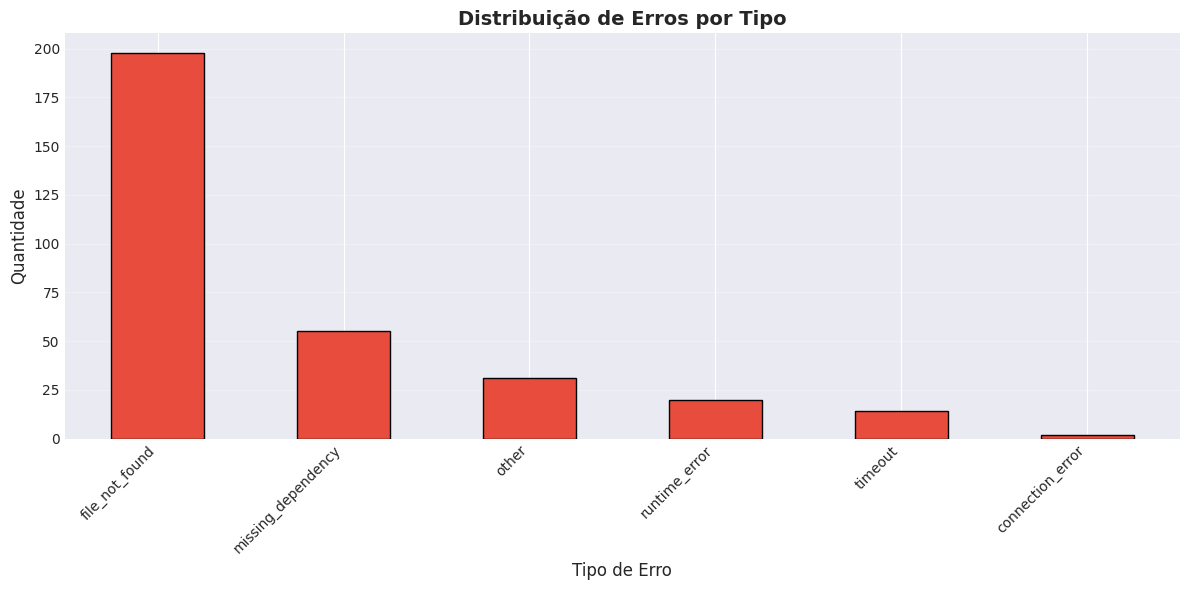

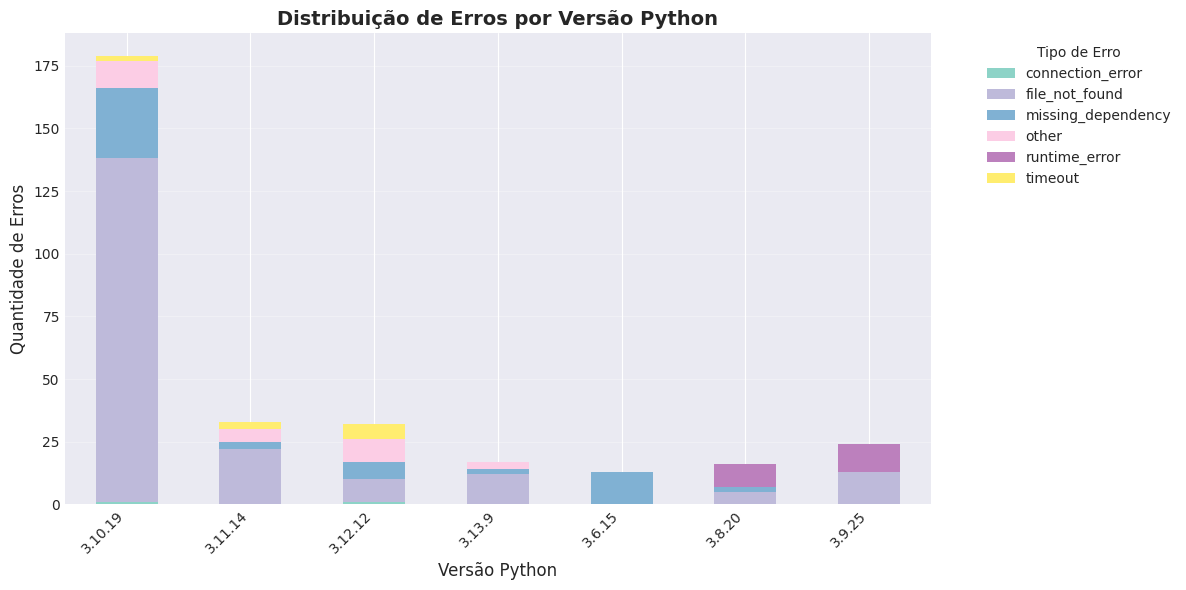

In [31]:
# Análise Detalhada de Erros de Execução

print("🔍 Análise Detalhada de Erros de Execução\n")

if df_master.empty:
    print("⚠️  df_master está vazio. Verifique o Bloco 1.")
else:
    # Filtrar apenas execuções que falharam
    df_failed = df_master[~df_master.get('exec_ok', pd.Series(dtype=bool))].copy()
    df_success = df_master[df_master.get('exec_ok', pd.Series(dtype=bool))].copy()
    
    total_exec = len(df_master)
    n_failed = len(df_failed)
    n_success = len(df_success)
    
    print("="*60)
    print("RESUMO GERAL DE EXECUÇÕES")
    print("="*60)
    print(f"  - Total de execuções: {total_exec}")
    print(f"  - Sucessos: {n_success} ({n_success/total_exec*100:.1f}%)")
    print(f"  - Falhas: {n_failed} ({n_failed/total_exec*100:.1f}%)")
    
    if n_failed == 0:
        print("\n✓ Nenhuma falha encontrada!")
    else:
        print("\n" + "="*60)
        print("TIPOS DE ERRO (exec_error_type)")
        print("="*60)
        
        # Análise por tipo de erro
        if 'exec_error_type' in df_failed.columns:
            error_counts = df_failed['exec_error_type'].fillna('unknown').value_counts()
            error_pct = (error_counts / n_failed * 100).round(1)
            
            error_summary = pd.DataFrame({
                'tipo_erro': error_counts.index,
                'quantidade': error_counts.values,
                'percentual': error_pct.values
            }).sort_values('quantidade', ascending=False)
            
            print("\nDistribuição de erros por tipo:")
            print(error_summary.to_string(index=False))
            
            # Salvar resumo de erros
            error_summary_path = DATA_OUTPUTS / 'error_analysis_summary.csv'
            error_summary.to_csv(error_summary_path, index=False)
            print(f"\n✓ Resumo de erros salvo: {error_summary_path}")
            
            # Gráfico de barras - tipos de erro
            fig, ax = plt.subplots(figsize=(12, 6))
            error_counts.plot(kind='bar', color='#e74c3c', edgecolor='black', ax=ax)
            ax.set_xlabel('Tipo de Erro', fontsize=12)
            ax.set_ylabel('Quantidade', fontsize=12)
            ax.set_title('Distribuição de Erros por Tipo', fontsize=14, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            fig_path = FIG_DIR / 'error_analysis_by_type.png'
            fig.savefig(fig_path, dpi=150)
            print(f"✓ Figura salva: {fig_path}")
        
        # ANÁLISE GRANULAR: Tabela cruzada entre exec_error_type e exec_exception_type
        print("\n" + "="*60)
        print("ANÁLISE GRANULAR: O que são os erros 'other'?")
        print("="*60)
        
        if 'exec_error_type' in df_failed.columns and 'exec_exception_type' in df_failed.columns:
            # Criar tabela cruzada
            cross_tab = pd.crosstab(
                df_failed['exec_error_type'].fillna('unknown'),
                df_failed['exec_exception_type'].fillna('unknown'),
                margins=True
            )
            
            print("\nTabela cruzada: exec_error_type vs exec_exception_type")
            print(cross_tab.to_string())
            
            # Salvar tabela cruzada
            cross_tab_path = DATA_OUTPUTS / 'error_cross_tabulation.csv'
            cross_tab.to_csv(cross_tab_path)
            print(f"\n✓ Tabela cruzada salva: {cross_tab_path}")
            
            # Foco especial nos erros "other"
            if 'other' in df_failed['exec_error_type'].values:
                df_other = df_failed[df_failed['exec_error_type'] == 'other'].copy()
                print("\n" + "="*60)
                print("DETALHAMENTO DOS ERROS 'other'")
                print("="*60)
                print(f"\nTotal de erros categorizados como 'other': {len(df_other)}")
                
                # Tipos de exceção Python dentro de "other"
                if 'exec_exception_type' in df_other.columns:
                    other_exc_counts = df_other['exec_exception_type'].fillna('unknown').value_counts()
                    other_exc_pct = (other_exc_counts / len(df_other) * 100).round(1)
                    
                    other_exc_summary = pd.DataFrame({
                        'tipo_excecao_python': other_exc_counts.index,
                        'quantidade': other_exc_counts.values,
                        'percentual_dos_other': other_exc_pct.values,
                        'percentual_das_falhas': ((other_exc_counts / n_failed) * 100).round(1).values
                    }).sort_values('quantidade', ascending=False)
                    
                    print("\n📊 Tipos de exceção Python dentro de 'other':")
                    print(other_exc_summary.to_string(index=False))
                    
                    # Salvar detalhamento dos "other"
                    other_detail_path = DATA_OUTPUTS / 'error_other_detailed.csv'
                    other_exc_summary.to_csv(other_detail_path, index=False)
                    print(f"\n✓ Detalhamento dos 'other' salvo: {other_detail_path}")
                    
                    # Exemplos de mensagens de erro para cada tipo de exceção em "other"
                    print("\n" + "="*60)
                    print("EXEMPLOS DE MENSAGENS DE ERRO - CATEGORIA 'other'")
                    print("="*60)
                    
                    if 'exec_exception_str' in df_other.columns:
                        for exc_type in other_exc_counts.head(10).index:
                            examples = df_other[df_other['exec_exception_type'] == exc_type]
                            if not examples.empty and 'exec_exception_str' in examples.columns:
                                msgs = examples['exec_exception_str'].dropna().unique()[:2]
                                print(f"\n🔍 {exc_type} ({other_exc_counts[exc_type]} ocorrências em 'other'):")
                                for i, msg in enumerate(msgs, 1):
                                    # Truncar mensagens muito longas
                                    msg_display = msg[:300] + "..." if len(msg) > 300 else msg
                                    print(f"   Exemplo {i}: {msg_display}")
        
        # TODOS os tipos de exceção Python (granularidade completa)
        print("\n" + "="*60)
        print("TODOS OS TIPOS DE EXCEÇÃO PYTHON (GRANULARIDADE COMPLETA)")
        print("="*60)
        
        if 'exec_exception_type' in df_failed.columns:
            exc_counts_all = df_failed['exec_exception_type'].fillna('unknown').value_counts()
            exc_pct_all = (exc_counts_all / n_failed * 100).round(2)
            
            exc_summary_all = pd.DataFrame({
                'tipo_excecao_python': exc_counts_all.index,
                'quantidade': exc_counts_all.values,
                'percentual': exc_pct_all.values
            }).sort_values('quantidade', ascending=False)
            
            print(f"\nTotal de tipos de exceção distintos: {len(exc_summary_all)}")
            print("\nDistribuição completa de tipos de exceção Python:")
            print(exc_summary_all.to_string(index=False))
            
            # Salvar todos os tipos de exceção
            exc_all_path = DATA_OUTPUTS / 'error_all_exception_types.csv'
            exc_summary_all.to_csv(exc_all_path, index=False)
            print(f"\n✓ Lista completa de tipos de exceção salva: {exc_all_path}")
            
            # Para cada tipo de exceção, mostrar exemplos de mensagens
            print("\n" + "="*60)
            print("EXEMPLOS DE MENSAGENS POR TIPO DE EXCEÇÃO PYTHON")
            print("="*60)
            
            if 'exec_exception_str' in df_failed.columns:
                for exc_type in exc_counts_all.head(20).index:
                    examples = df_failed[df_failed['exec_exception_type'] == exc_type]
                    if not examples.empty and 'exec_exception_str' in examples.columns:
                        msgs = examples['exec_exception_str'].dropna().unique()[:1]
                        if msgs:
                            msg_display = msgs[0][:250] + "..." if len(msgs[0]) > 250 else msgs[0]
                            print(f"\n📌 {exc_type} ({exc_counts_all[exc_type]} ocorrências):")
                            print(f"   {msg_display}")
        
        # Análise: quais tipos de exceção estão em cada categoria de erro
        print("\n" + "="*60)
        print("MAPEAMENTO: exec_error_type → exec_exception_type")
        print("="*60)
        
        if 'exec_error_type' in df_failed.columns and 'exec_exception_type' in df_failed.columns:
            for error_cat in df_failed['exec_error_type'].fillna('unknown').unique():
                df_cat = df_failed[df_failed['exec_error_type'] == error_cat]
                if 'exec_exception_type' in df_cat.columns:
                    exc_in_cat = df_cat['exec_exception_type'].fillna('unknown').value_counts()
                    print(f"\n📁 Categoria '{error_cat}' ({len(df_cat)} ocorrências):")
                    for exc_type, count in exc_in_cat.head(10).items():
                        pct = round(count / len(df_cat) * 100, 1)
                        print(f"   - {exc_type}: {count} ({pct}% desta categoria)")
                    if len(exc_in_cat) > 10:
                        print(f"   ... e mais {len(exc_in_cat) - 10} tipos")
        
        # Análise por repositório
        print("\n" + "="*60)
        print("REPOSITÓRIOS COM MAIS FALHAS")
        print("="*60)
        
        if 'repo_full_name' in df_failed.columns:
            repo_failures = df_failed['repo_full_name'].value_counts().head(10)
            repo_summary = pd.DataFrame({
                'repositorio': repo_failures.index,
                'falhas': repo_failures.values
            })
            
            print("\nTop 10 repositórios com mais falhas:")
            print(repo_summary.to_string(index=False))
            
            # Salvar análise por repositório
            repo_analysis_path = DATA_OUTPUTS / 'error_analysis_by_repo.csv'
            repo_summary.to_csv(repo_analysis_path, index=False)
            print(f"\n✓ Análise por repositório salva: {repo_analysis_path}")
        
        # Análise de erros por versão Python
        print("\n" + "="*60)
        print("ERROS POR VERSÃO PYTHON")
        print("="*60)
        
        if 'exec_env_python_version' in df_failed.columns:
            py_errors = df_failed.groupby('exec_env_python_version')['exec_error_type'].value_counts().unstack(fill_value=0)
            if not py_errors.empty:
                print("\nDistribuição de erros por versão Python:")
                print(py_errors.to_string())
                
                # Gráfico empilhado
                fig, ax = plt.subplots(figsize=(12, 6))
                py_errors.plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
                ax.set_xlabel('Versão Python', fontsize=12)
                ax.set_ylabel('Quantidade de Erros', fontsize=12)
                ax.set_title('Distribuição de Erros por Versão Python', fontsize=14, fontweight='bold')
                ax.legend(title='Tipo de Erro', bbox_to_anchor=(1.05, 1), loc='upper left')
                ax.grid(axis='y', alpha=0.3)
                plt.xticks(rotation=45, ha='right')
                plt.tight_layout()
                fig_path = FIG_DIR / 'error_analysis_by_python_version.png'
                fig.savefig(fig_path, dpi=150)
                print(f"\n✓ Figura salva: {fig_path}")
        
        # Análise de tracebacks (exemplos)
        print("\n" + "="*60)
        print("ANÁLISE DE TRACEBACKS")
        print("="*60)
        
        if 'exec_traceback_str' in df_failed.columns:
            # Contar quantos têm traceback
            has_traceback = df_failed['exec_traceback_str'].notna().sum()
            print(f"\n  - Execuções com traceback disponível: {has_traceback}/{n_failed} ({has_traceback/n_failed*100:.1f}%)")
            
            # Exemplo de traceback mais comum (primeiro erro que aparece)
            if has_traceback > 0:
                traceback_examples = df_failed[df_failed['exec_traceback_str'].notna()].head(1)
                if not traceback_examples.empty:
                    example_tb = traceback_examples.iloc[0]['exec_traceback_str']
                    # Mostrar primeiras linhas do traceback
                    tb_lines = example_tb.split('\n')[:10]
                    print(f"\n  Exemplo de traceback (primeiras 10 linhas):")
                    for line in tb_lines:
                        print(f"    {line}")

print("\n" + "="*60)
print("Análise de erros concluída!")
print("="*60)




## BLOCO 2: RQ1 - Taxa de Reprodutibilidade em 2025

Calcular métricas de reprodutibilidade: `exec_ok` rate, `outputs_equal` rate (todos e condicionado a `exec_ok`). Gerar tabelas e gráficos por versão Python, env_spec, etc.


📊 RQ1: Taxa de Reprodutibilidade em 2025

MÉTRICAS DE REPRODUTIBILIDADE (2025)
  - Total de notebooks: 395
  - Execution Rate (exec_ok): 19.0% (75/395)
  - Reproduction Rate (all, outputs_equal): 3.5% (14/395)
  - Reproduction Rate (cond. exec_ok): 18.7% (14/75)
✓ Figura salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq1_exec_ok_by_python.png
✓ Figura salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq1_exec_ok_by_envspec.png
✓ Top erros salvo: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq1_errors_top.csv
✓ Resumo salvo: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq1_summary.csv



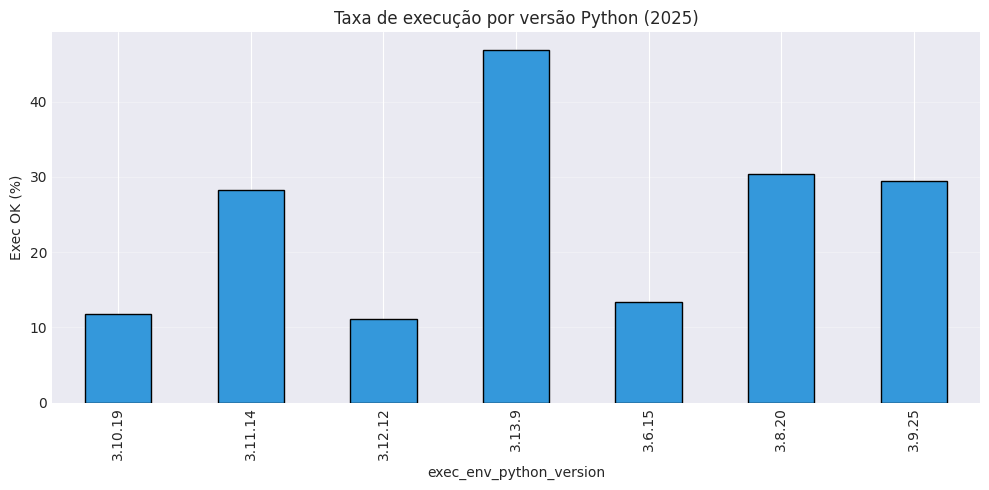

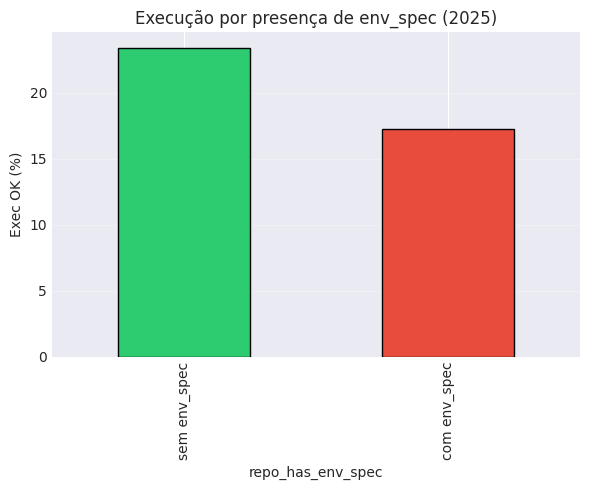

In [32]:
# RQ1: Taxa de Reprodutibilidade em 2025

print("📊 RQ1: Taxa de Reprodutibilidade em 2025\n")

if df_master.empty:
    print("⚠️  df_master está vazio. Verifique o Bloco 1.")
else:
    # Filtrar notebooks de 2025 (quando disponível)
    if 'repo_created_at' in df_master.columns:
        df2025 = df_master[df_master['repo_created_at'].astype(str).str.contains("2025", na=False)].copy()
    else:
        df2025 = df_master.copy()
        print("ℹ️  Coluna 'repo_created_at' ausente, usando todos os dados")
    
    n_total = len(df2025)
    exec_ok_count = int(df2025.get('exec_ok', pd.Series(dtype=bool)).fillna(False).sum()) if 'exec_ok' in df2025.columns else 0
    outputs_equal_count = int(df2025.get('outputs_equal', pd.Series(dtype=bool)).fillna(False).sum()) if 'outputs_equal' in df2025.columns else 0
    
    exec_rate = (exec_ok_count / n_total * 100.0) if n_total else 0.0
    repro_all_rate = (outputs_equal_count / n_total * 100.0) if n_total else 0.0
    
    df_exec_ok = df2025[df2025.get('exec_ok', False)] if 'exec_ok' in df2025.columns else pd.DataFrame()
    if not df_exec_ok.empty and 'outputs_equal' in df_exec_ok.columns:
        repro_strict_count = int(df_exec_ok['outputs_equal'].fillna(False).sum())
        repro_strict_rate = (repro_strict_count / len(df_exec_ok) * 100.0) if len(df_exec_ok) else 0.0
    else:
        repro_strict_count, repro_strict_rate = 0, 0.0
    
    # Exibir resultados
    print("="*60)
    print("MÉTRICAS DE REPRODUTIBILIDADE (2025)")
    print("="*60)
    print(f"  - Total de notebooks: {n_total}")
    print(f"  - Execution Rate (exec_ok): {exec_rate:.1f}% ({exec_ok_count}/{n_total})")
    print(f"  - Reproduction Rate (all, outputs_equal): {repro_all_rate:.1f}% ({outputs_equal_count}/{n_total})")
    print(f"  - Reproduction Rate (cond. exec_ok): {repro_strict_rate:.1f}% ({repro_strict_count}/{len(df_exec_ok) if len(df_exec_ok)>0 else 0})")
    
    # Quebras por versão Python
    if 'exec_env_python_version' in df2025.columns:
        by_py = (df2025.groupby('exec_env_python_version')['exec_ok']
                       .mean().sort_index() * 100.0)
        fig, ax = plt.subplots(figsize=(10,5))
        by_py.plot(kind='bar', color='#3498db', edgecolor='black', ax=ax)
        ax.set_ylabel('Exec OK (%)')
        ax.set_title('Taxa de execução por versão Python (2025)')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        fig_path = FIG_DIR / 'rq1_exec_ok_by_python.png'
        fig.savefig(fig_path, dpi=150)
        print(f"✓ Figura salva: {fig_path}")
    else:
        print("ℹ️  Coluna 'exec_env_python_version' ausente")
    
    # Quebras por env spec
    if 'repo_has_env_spec' in df2025.columns:
        by_env = (df2025.groupby('repo_has_env_spec')['exec_ok']
                        .mean() * 100.0).rename({True:'com env_spec', False:'sem env_spec'})
        fig, ax = plt.subplots(figsize=(6,5))
        by_env.plot(kind='bar', color=['#2ecc71','#e74c3c'], edgecolor='black', ax=ax)
        ax.set_ylabel('Exec OK (%)')
        ax.set_title('Execução por presença de env_spec (2025)')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        fig_path = FIG_DIR / 'rq1_exec_ok_by_envspec.png'
        fig.savefig(fig_path, dpi=150)
        print(f"✓ Figura salva: {fig_path}")
    else:
        print("ℹ️  Coluna 'repo_has_env_spec' ausente")
    
    # Top tipos de erro
    if 'exec_error_type' in df2025.columns and 'exec_ok' in df2025.columns:
        errs = (df2025[~df2025['exec_ok']]['exec_error_type']
                    .fillna('unknown').value_counts().head(10))
        top_errors = errs.reset_index()
        top_errors.columns = ['exec_error_type','count']
        out_errs = DATA_OUTPUTS / 'rq1_errors_top.csv'
        top_errors.to_csv(out_errs, index=False)
        print(f"✓ Top erros salvo: {out_errs}")
    
    # Exportar resumo
    summary_rows = [{
        'metric_name': 'exec_ok_ratio_2025',
        'value': round(exec_rate/100.0, 6),
    },{
        'metric_name': 'outputs_equal_ratio_all_2025',
        'value': round(repro_all_rate/100.0, 6),
    },{
        'metric_name': 'outputs_equal_ratio_cond_exec_ok_2025',
        'value': round(repro_strict_rate/100.0, 6),
    }]
    out_summary = DATA_OUTPUTS / 'rq1_summary.csv'
    pd.DataFrame(summary_rows).to_csv(out_summary, index=False)
    print(f"✓ Resumo salvo: {out_summary}")

print("\n" + "="*60)


---

## BLOCO 3: RQ2 - Prevalência de Más Práticas

Calcular prevalência das flags `bad_*` (implementação da taxonomia Pimentel 2019) e comparar com os valores de referência de 2018.


📊 RQ2: Más práticas em 2025 + comparação com 2018 (Pimentel)

✓ Frequências de 2025 salvas: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq2_bad_practices_2025.csv
✓ Comparação Pimentel salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq2_pimentel_comparison.csv


✓ Figura salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq2_pimentel_comparison.png



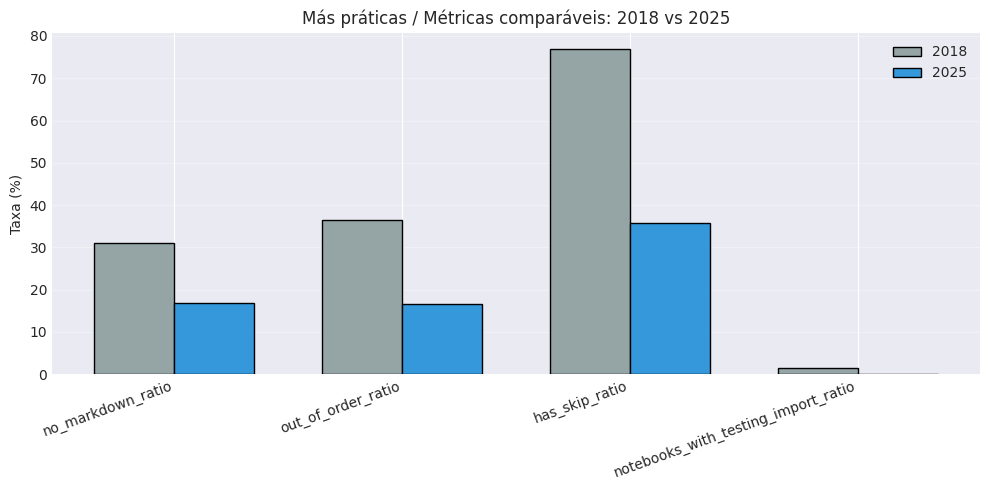

In [33]:
# RQ2: Más práticas (2025) e comparação com Pimentel 2019

print("📊 RQ2: Más práticas em 2025 + comparação com 2018 (Pimentel)\n")

# Base para flags: preferir collection.csv (fonte das flags), senão usar df_master
src = df_collection.copy() if not df_collection.empty else df_master.copy()
if 'repo_created_at' in src.columns:
    src = src[src['repo_created_at'].astype(str).str.contains("2025", na=False)].copy()

total = len(src)
if total == 0:
    print("⚠️  Sem dados para 2025 na base de flags.")
else:
    # Flags de más práticas (taxonomia Pimentel 2019)
    flags = [
        'bad_no_markdown', 'bad_low_markdown_ratio', 'bad_untitled', 'bad_copy_name',
        'bad_non_portable_name', 'bad_no_functions', 'bad_no_local_imports', 'bad_no_testing_imports',
        'bad_out_of_order_exec', 'bad_has_exec_skips', 'bad_has_non_executed_code_in_middle',
    ]
    # Features de repo
    repo_feats = ['repo_has_env_spec', 'repo_has_ci_workflow', 'repo_has_tests_dir', 'repo_has_data_dir']

    records = []
    for col in flags:
        if col in src.columns:
            v = src[col].map(to_bool).mean()
            cnt = int(src[col].map(to_bool).sum())
            records.append({'metric_name': col, 'count': cnt, 'total': total, 'ratio_2025': round(v, 6)})
    for col in repo_feats:
        if col in src.columns:
            v = src[col].map(to_bool).mean()
            cnt = int(src[col].map(to_bool).sum())
            records.append({'metric_name': col, 'count': cnt, 'total': total, 'ratio_2025': round(v, 6)})

    df_rq2 = pd.DataFrame(records)
    out_rq2 = DATA_OUTPUTS / 'rq2_bad_practices_2025.csv'
    df_rq2.to_csv(out_rq2, index=False)
    print(f"✓ Frequências de 2025 salvas: {out_rq2}")

    # Comparação com Pimentel 2019 (usar exclusivamente o JSON)
    comp_items = []

    # 1) no_markdown_ratio
    r2018_no_md = pimentel_ref.get('metrics', {}).get('rq1_literate_programming', {}).get('no_markdown_ratio', None)
    r2025_no_md = float(df_rq2.loc[df_rq2['metric_name'] == 'bad_no_markdown', 'ratio_2025'].iloc[0]) if 'bad_no_markdown' in df_rq2['metric_name'].values else None
    if r2018_no_md is not None and r2025_no_md is not None:
        comp_items.append({'metric_name': 'no_markdown_ratio', 'value_2018': r2018_no_md, 'value_2025': r2025_no_md})

    # 2) out_of_order_ratio
    r2018_ooo = pimentel_ref.get('metrics', {}).get('rq6_execution_order', {}).get('out_of_order_ratio', None)
    r2025_ooo = float(df_rq2.loc[df_rq2['metric_name'] == 'bad_out_of_order_exec', 'ratio_2025'].iloc[0]) if 'bad_out_of_order_exec' in df_rq2['metric_name'].values else None
    if r2018_ooo is not None and r2025_ooo is not None:
        comp_items.append({'metric_name': 'out_of_order_ratio', 'value_2018': r2018_ooo, 'value_2025': r2025_ooo})

    # 3) has_skip_ratio
    r2018_skip = pimentel_ref.get('metrics', {}).get('rq6_execution_order', {}).get('has_skip_ratio', None)
    r2025_skip = float(df_rq2.loc[df_rq2['metric_name'] == 'bad_has_exec_skips', 'ratio_2025'].iloc[0]) if 'bad_has_exec_skips' in df_rq2['metric_name'].values else None
    if r2018_skip is not None and r2025_skip is not None:
        comp_items.append({'metric_name': 'has_skip_ratio', 'value_2018': r2018_skip, 'value_2025': r2025_skip})

    # 4) notebooks_with_testing_import_ratio
    r2018_test = pimentel_ref.get('metrics', {}).get('rq4_testing', {}).get('notebooks_with_testing_import_ratio', None)
    if 'uses_testing_module' in src.columns:
        r2025_test = float(src['uses_testing_module'].map(to_bool).mean())
    elif 'bad_no_testing_imports' in src.columns:
        r2025_test = float(1.0 - src['bad_no_testing_imports'].map(to_bool).mean())
    else:
        r2025_test = None
    if r2018_test is not None and r2025_test is not None:
        comp_items.append({'metric_name': 'notebooks_with_testing_import_ratio', 'value_2018': r2018_test, 'value_2025': round(r2025_test, 6)})

    df_comp = pd.DataFrame(comp_items)
    out_comp = DATA_OUTPUTS / 'rq2_pimentel_comparison.csv'
    df_comp.to_csv(out_comp, index=False)
    print(f"✓ Comparação Pimentel salva: {out_comp}")

    # Gráfico: barras lado a lado (2018 vs 2025)
    if not df_comp.empty:
        fig, ax = plt.subplots(figsize=(10,5))
        x = np.arange(len(df_comp))
        w = 0.35
        ax.bar(x - w/2, df_comp['value_2018'] * 100.0, width=w, label='2018', color='#95a5a6', edgecolor='black')
        ax.bar(x + w/2, df_comp['value_2025'] * 100.0, width=w, label='2025', color='#3498db', edgecolor='black')
        ax.set_xticks(x)
        ax.set_xticklabels(df_comp['metric_name'], rotation=20, ha='right')
        ax.set_ylabel('Taxa (%)')
        ax.set_title('Más práticas / Métricas comparáveis: 2018 vs 2025')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        fig_path = FIG_DIR / 'rq2_pimentel_comparison.png'
        fig.savefig(fig_path, dpi=150)
        print(f"✓ Figura salva: {fig_path}")

print("\n" + "="*60)


---

## BLOCO 4: RQ3 - Fatores que Impactam Reprodutibilidade

Construir dataset analítico e treinar modelos (regressão logística) para identificar fatores que mais impactam a reprodutibilidade.


📊 RQ3: Fatores que Impactam Reprodutibilidade

⚠️  Falha na regressão statsmodels: Singular matrix
✓ Acurácia (in-sample): 0.873
✓ Importâncias salvas: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq3_factor_importance.csv
✓ Figura salva: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq3_feature_importance.png

RQ3 concluída!


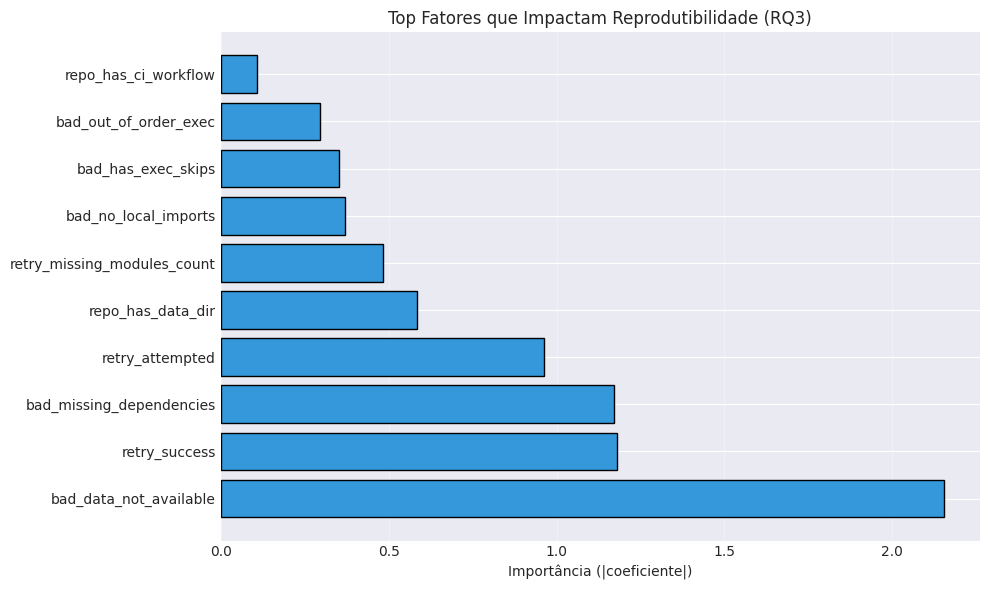

In [34]:
# RQ3: Fatores que Impactam Reprodutibilidade

print("📊 RQ3: Fatores que Impactam Reprodutibilidade\n")

# Construir dataset analítico a partir do master
if df_master.empty:
    print("⚠️  df_master está vazio. Verifique o Bloco 1.")
else:
    # Montar conjunto analítico
    use_df = df_master.copy()
    
    # Garantir tipos numéricos/booleanos coerentes
    bool_cols = [
        'exec_ok','outputs_equal','bad_no_markdown','bad_no_local_imports','bad_no_testing_imports',
        'bad_out_of_order_exec','bad_has_exec_skips','repo_has_env_spec','repo_has_ci_workflow',
        'repo_has_tests_dir','repo_has_data_dir','retry_attempted','retry_success'
    ]
    for c in bool_cols:
        if c in use_df.columns:
            use_df[c] = use_df[c].map(lambda x: 1 if to_bool(x) else 0)
    
    if 'retry_missing_modules_count' in use_df.columns:
        use_df['retry_missing_modules_count'] = pd.to_numeric(use_df['retry_missing_modules_count'], errors='coerce').fillna(0).astype(int)
    
    # Derivar flags de erro
    if 'exec_error_type' in use_df.columns:
        use_df['bad_missing_dependencies'] = (use_df['exec_error_type'] == 'missing_dependency').astype(int)
        use_df['bad_data_not_available'] = (use_df['exec_error_type'] == 'file_not_found').astype(int)
    
    # Seleção de preditores
    predictors = [
        'bad_no_markdown','bad_no_local_imports','bad_no_testing_imports',
        'bad_out_of_order_exec','bad_has_exec_skips',
        'repo_has_env_spec','repo_has_ci_workflow','repo_has_tests_dir','repo_has_data_dir',
        'bad_missing_dependencies','bad_data_not_available',
        'retry_attempted','retry_success','retry_missing_modules_count'
    ]
    predictors = [p for p in predictors if p in use_df.columns]
    
    # Preparar dados para modelo
    df_model = use_df[predictors + ['exec_ok']].dropna().copy()
    
    # Type coercion final
    for c in predictors + ['exec_ok']:
        if df_model[c].dtype == 'bool':
            df_model[c] = df_model[c].astype(int)
        df_model[c] = pd.to_numeric(df_model[c], errors='coerce')
    df_model = df_model.dropna()
    
    if len(df_model) < 30 or len(predictors) == 0:
        print("⚠️  Dados insuficientes para regressão.")
    else:
        # 1) Regressão logística com statsmodels (ORs e p-values)
        try:
            import statsmodels.api as sm
            X = df_model[predictors].astype(float)
            y = df_model['exec_ok'].astype(int)
            X_const = sm.add_constant(X, has_constant='add')
            logit = sm.Logit(y, X_const)
            res = logit.fit(disp=False)
            coefs = res.params
            pvals = res.pvalues
            ors = np.exp(coefs)
            conf = res.conf_int()
            conf.columns = ['ci_lower','ci_upper']
            conf_exp = np.exp(conf)
            out_df = pd.concat([coefs.rename('coef'), ors.rename('OR'), pvals.rename('p_value'), conf_exp], axis=1)
            out_df.index.name = 'feature'
            out_df.reset_index(inplace=True)
            out_df = out_df[out_df['feature'] != 'const']
            coef_path = DATA_OUTPUTS / 'rq3_coefficients.csv'
            out_df.to_csv(coef_path, index=False)
            print(f"✓ Coeficientes/ORs salvos: {coef_path}")
        except Exception as e:
            print(f"⚠️  Falha na regressão statsmodels: {e}")
            out_df = pd.DataFrame()
        
        # 2) Validação com scikit-learn (feature importance)
        try:
            from sklearn.linear_model import LogisticRegression
            from sklearn.preprocessing import StandardScaler
            from sklearn.pipeline import make_pipeline
            model = make_pipeline(StandardScaler(with_mean=False), LogisticRegression(max_iter=1000, solver='lbfgs'))
            model.fit(df_model[predictors].astype(float), df_model['exec_ok'].astype(int))
            acc = model.score(df_model[predictors].astype(float), df_model['exec_ok'].astype(int))
            print(f"✓ Acurácia (in-sample): {acc:.3f}")
            
            # Feature importance (coeficientes absolutos)
            try:
                lr = model.named_steps['logisticregression']
                imps = np.abs(lr.coef_[0])
                imp_df = pd.DataFrame({'feature': predictors, 'importance': imps}).sort_values('importance', ascending=False)
                imp_path = DATA_OUTPUTS / 'rq3_factor_importance.csv'
                imp_df.to_csv(imp_path, index=False)
                print(f"✓ Importâncias salvas: {imp_path}")
                
                # Gráfico de feature importance
                fig, ax = plt.subplots(figsize=(10, 6))
                top_n = min(10, len(imp_df))
                top_imp = imp_df.head(top_n)
                ax.barh(range(len(top_imp)), top_imp['importance'], color='#3498db', edgecolor='black')
                ax.set_yticks(range(len(top_imp)))
                ax.set_yticklabels(top_imp['feature'])
                ax.set_xlabel('Importância (|coeficiente|)')
                ax.set_title('Top Fatores que Impactam Reprodutibilidade (RQ3)')
                ax.grid(axis='x', alpha=0.3)
                plt.tight_layout()
                fig_path = FIG_DIR / 'rq3_feature_importance.png'
                fig.savefig(fig_path, dpi=150)
                print(f"✓ Figura salva: {fig_path}")
            except Exception as e:
                print(f"⚠️  Falha ao gerar feature importance: {e}")
        except Exception as e:
            print(f"⚠️  Validação sklearn falhou: {e}")

print("\n" + "="*60)
print("RQ3 concluída!")
print("="*60)

---

## BLOCO 6: Análise Exploratória - Correlação Repo-Falha

Análise de correlação entre características estruturais do repositório (repo_has_tests_dir, repo_has_data_dir, repo_has_ci_workflow, etc.) e taxa de sucesso na execução.



📊 Bloco 6: Análise Exploratória - Correlação Repo-Falha

Correlação entre características do repositório e taxa de sucesso:
                  feature      chi2      p_value  success_rate_with  success_rate_without  difference  n_with  n_without
repo_has_requirements_txt 17.252223 3.273143e-05           0.289157              0.117904    0.171253     166        229
     repo_has_ci_workflow  0.462654 4.963863e-01           0.333333              0.186528    0.146805       9        386
        repo_has_env_spec  1.594333 2.067082e-01           0.172535              0.234234   -0.061699     284        111
       repo_has_tests_dir  0.010584 9.180599e-01           0.000000              0.191327   -0.191327       3        392
        repo_has_setup_py  3.722889 5.367144e-02           0.000000              0.200000   -0.200000      20        375
        repo_has_data_dir 37.697044 8.262969e-10           0.000000              0.270758   -0.270758     118        277


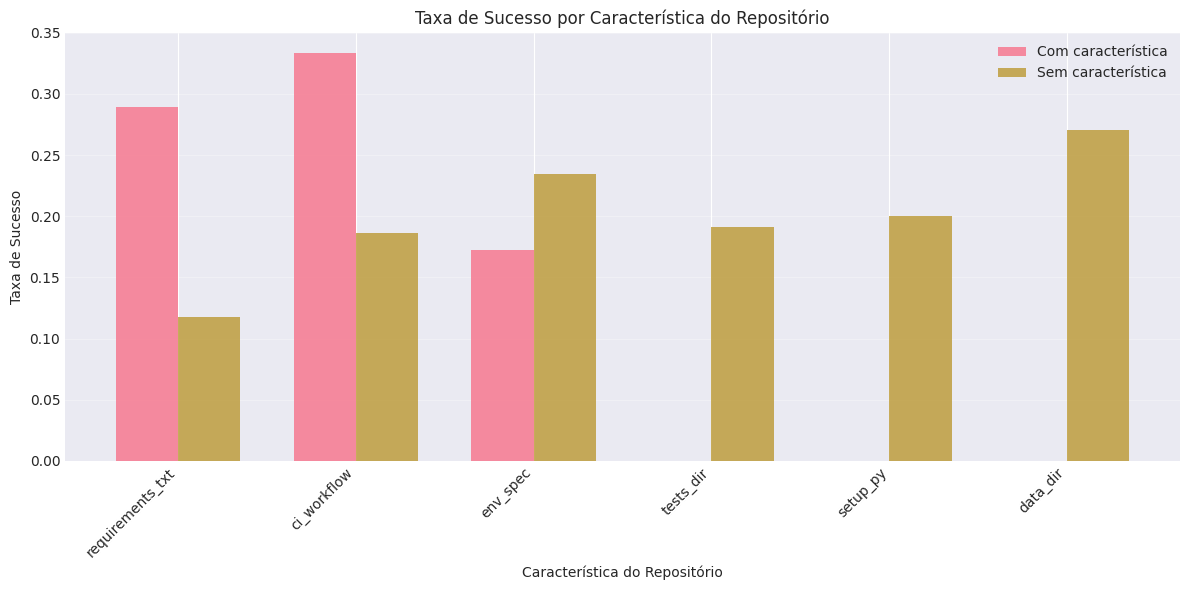


✓ Resultados salvos em: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq6_repo_features_correlation.csv
✓ Figura salva em: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq6_repo_features_success.png


In [35]:
# === BLOCO 6: ANÁLISE EXPLORATÓRIA - CORRELAÇÃO REPO-FALHA ===

print("📊 Bloco 6: Análise Exploratória - Correlação Repo-Falha\n")

if df_master.empty:
    print("⚠️  df_master está vazio. Verifique o Bloco 1.")
else:
    import scipy.stats as stats
    from scipy.stats import chi2_contingency
    
    # Preparar dados
    analysis_df = df_master.copy()
    
    # Garantir tipos booleanos
    bool_cols = [
        'repo_has_tests_dir', 'repo_has_data_dir', 'repo_has_ci_workflow',
        'repo_has_env_spec', 'repo_has_requirements_txt', 'repo_has_setup_py',
        'exec_ok'
    ]
    for col in bool_cols:
        if col in analysis_df.columns:
            analysis_df[col] = analysis_df[col].map(to_bool)
    
    # Análise de correlação
    repo_features = [
        'repo_has_tests_dir', 'repo_has_data_dir', 'repo_has_ci_workflow',
        'repo_has_env_spec', 'repo_has_requirements_txt', 'repo_has_setup_py'
    ]
    
    correlation_results = []
    
    for feature in repo_features:
        if feature in analysis_df.columns:
            # Criar tabela de contingência
            contingency = pd.crosstab(analysis_df[feature], analysis_df['exec_ok'])
            
            if contingency.shape == (2, 2) and contingency.values.sum() > 0:
                # Teste chi-square
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                
                # Taxa de sucesso
                success_rate_with = analysis_df[analysis_df[feature] == True]['exec_ok'].mean() if True in analysis_df[feature].values else 0
                success_rate_without = analysis_df[analysis_df[feature] == False]['exec_ok'].mean() if False in analysis_df[feature].values else 0
                
                correlation_results.append({
                    'feature': feature,
                    'chi2': chi2,
                    'p_value': p_value,
                    'success_rate_with': success_rate_with,
                    'success_rate_without': success_rate_without,
                    'difference': success_rate_with - success_rate_without,
                    'n_with': (analysis_df[feature] == True).sum(),
                    'n_without': (analysis_df[feature] == False).sum()
                })
    
    # Criar DataFrame de resultados
    corr_df = pd.DataFrame(correlation_results)
    corr_df = corr_df.sort_values('difference', ascending=False)
    
    print("Correlação entre características do repositório e taxa de sucesso:")
    print(corr_df.to_string(index=False))
    
    # Visualização
    if not corr_df.empty:
        fig, ax = plt.subplots(figsize=(12, 6))
        x_pos = range(len(corr_df))
        width = 0.35
        
        ax.bar([x - width/2 for x in x_pos], corr_df['success_rate_with'], width, 
               label='Com característica', alpha=0.8)
        ax.bar([x + width/2 for x in x_pos], corr_df['success_rate_without'], width,
               label='Sem característica', alpha=0.8)
        
        ax.set_xlabel('Característica do Repositório')
        ax.set_ylabel('Taxa de Sucesso')
        ax.set_title('Taxa de Sucesso por Característica do Repositório')
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f.replace('repo_has_', '') for f in corr_df['feature']], rotation=45, ha='right')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(FIG_DIR / 'rq6_repo_features_success.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        # Salvar CSV
        corr_df.to_csv(DATA_OUTPUTS / 'rq6_repo_features_correlation.csv', index=False)
        print(f"\n✓ Resultados salvos em: {DATA_OUTPUTS / 'rq6_repo_features_correlation.csv'}")
        print(f"✓ Figura salva em: {FIG_DIR / 'rq6_repo_features_success.png'}")



---

## BLOCO 7: Análise Exploratória - CellExecutionError Detalhado

Análise detalhada dos erros CellExecutionError para identificar os erros reais mascarados dentro deles.



📊 Bloco 7: Análise Exploratória - CellExecutionError Detalhado

Total de CellExecutionError analisados: 311

Distribuição de tipos de erro real encontrados:
real_error_type
file_not_found        196
unclassified           50
missing_dependency     45
runtime_error          20


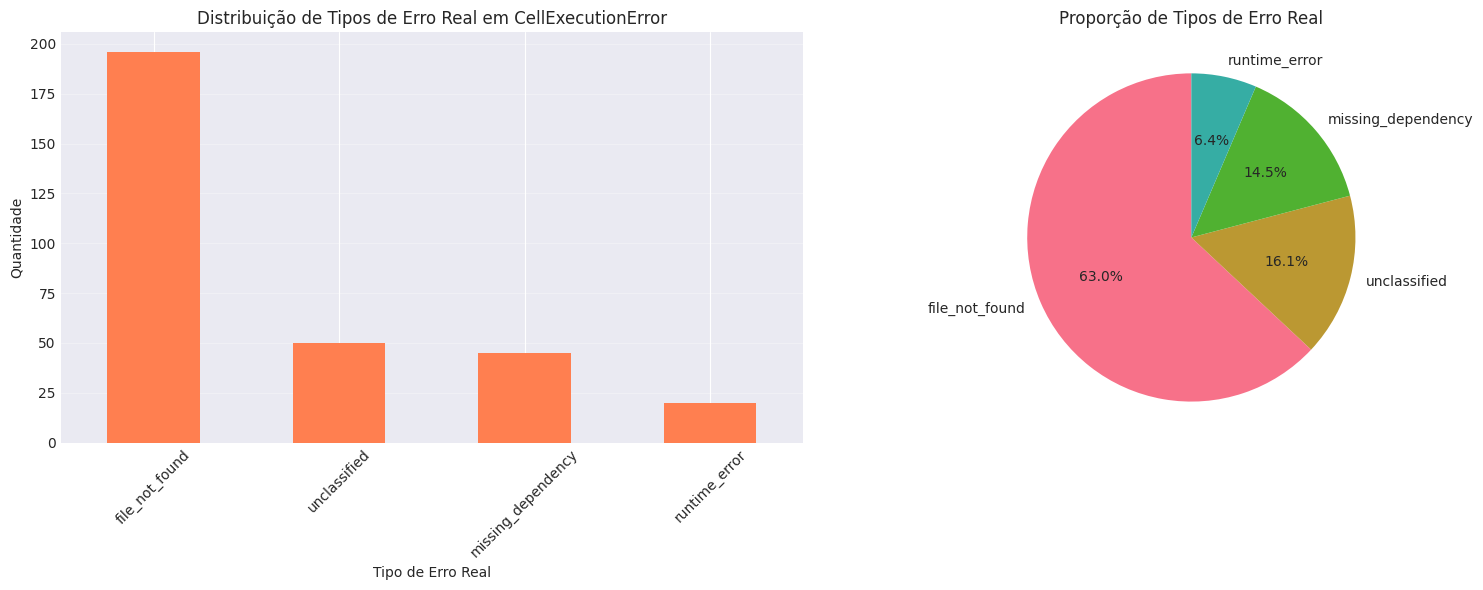


Top 10 repositórios com mais CellExecutionError:
real_error_type                        file_not_found  missing_dependency  runtime_error  unclassified  total
repo_full_name                                                                                               
As17-01/brain_signals                             111                   0              0             0    111
Subin-Vidhu/2025                                   24                   0             16            25     65
Saiful-Islam25/Machine-Learning                    28                   1              0             4     33
wewnumam/learn-ai                                  13                   7              0             3     23
ralf-42/GenAI                                       0                  20              0             0     20
rogerqiu7/Cancer-Mortality-Prediction               6                   0              1             0      7
Nikhild1093/Nikhild1093                             5                 

In [36]:
# === BLOCO 7: ANÁLISE EXPLORATÓRIA - CELLEXECUTIONERROR DETALHADO ===

print("📊 Bloco 7: Análise Exploratória - CellExecutionError Detalhado\n")

# Carregar análise de CellExecutionError se disponível
cellexecution_csv = DATA_OUTPUTS / "cellexecution_error_analysis.csv"

if cellexecution_csv.exists():
    df_cellexecution = pd.read_csv(cellexecution_csv)
    
    print(f"Total de CellExecutionError analisados: {len(df_cellexecution)}")
    
    # Distribuição de tipos de erro real
    real_error_dist = df_cellexecution['real_error_type'].value_counts()
    print("\nDistribuição de tipos de erro real encontrados:")
    print(real_error_dist.to_string())
    
    # Visualização
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Gráfico de barras
    real_error_dist.plot(kind='bar', ax=ax1, color='coral')
    ax1.set_title('Distribuição de Tipos de Erro Real em CellExecutionError')
    ax1.set_xlabel('Tipo de Erro Real')
    ax1.set_ylabel('Quantidade')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(axis='y', alpha=0.3)
    
    # Gráfico de pizza
    real_error_dist.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Proporção de Tipos de Erro Real')
    ax2.set_ylabel('')
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'rq7_cellexecution_error_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Análise por repositório
    repo_errors = df_cellexecution.groupby(['repo_full_name', 'real_error_type']).size().unstack(fill_value=0)
    repo_errors['total'] = repo_errors.sum(axis=1)
    repo_errors = repo_errors.sort_values('total', ascending=False).head(10)
    
    print("\nTop 10 repositórios com mais CellExecutionError:")
    print(repo_errors.to_string())
    
    # Salvar resultados
    real_error_dist.to_csv(DATA_OUTPUTS / 'rq7_real_error_distribution.csv')
    repo_errors.to_csv(DATA_OUTPUTS / 'rq7_repo_error_breakdown.csv')
    
    print(f"\n✓ Resultados salvos em:")
    print(f"  - {DATA_OUTPUTS / 'rq7_real_error_distribution.csv'}")
    print(f"  - {DATA_OUTPUTS / 'rq7_repo_error_breakdown.csv'}")
    print(f"  - {FIG_DIR / 'rq7_cellexecution_error_distribution.png'}")
else:
    print("⚠️  Arquivo cellexecution_error_analysis.csv não encontrado.")
    print("   Execute: python scripts/analyze_cellexecution_errors.py")



---

## BLOCO 8: Análise Exploratória - Comparação com Literatura

Comparação de resultados com estudos anteriores, especialmente Pimentel et al. (2019).



📊 Bloco 8: Análise Exploratória - Comparação com Literatura

Estudo Atual (2025):
  Total de notebooks: 395
  Taxa de sucesso: 19.0% (75/395)

Distribuição de erros:
  file_not_found: 198 (50.1%)
  ok: 75 (19.0%)
  missing_dependency: 55 (13.9%)
  other: 31 (7.8%)
  runtime_error: 20 (5.1%)
  timeout: 14 (3.5%)
  connection_error: 2 (0.5%)

Pimentel et al. (2019) - Referência:
  Taxa de sucesso: 24.0%
  Taxa de file_not_found: 15.0%
  Taxa de missing_dependency: 10.0%


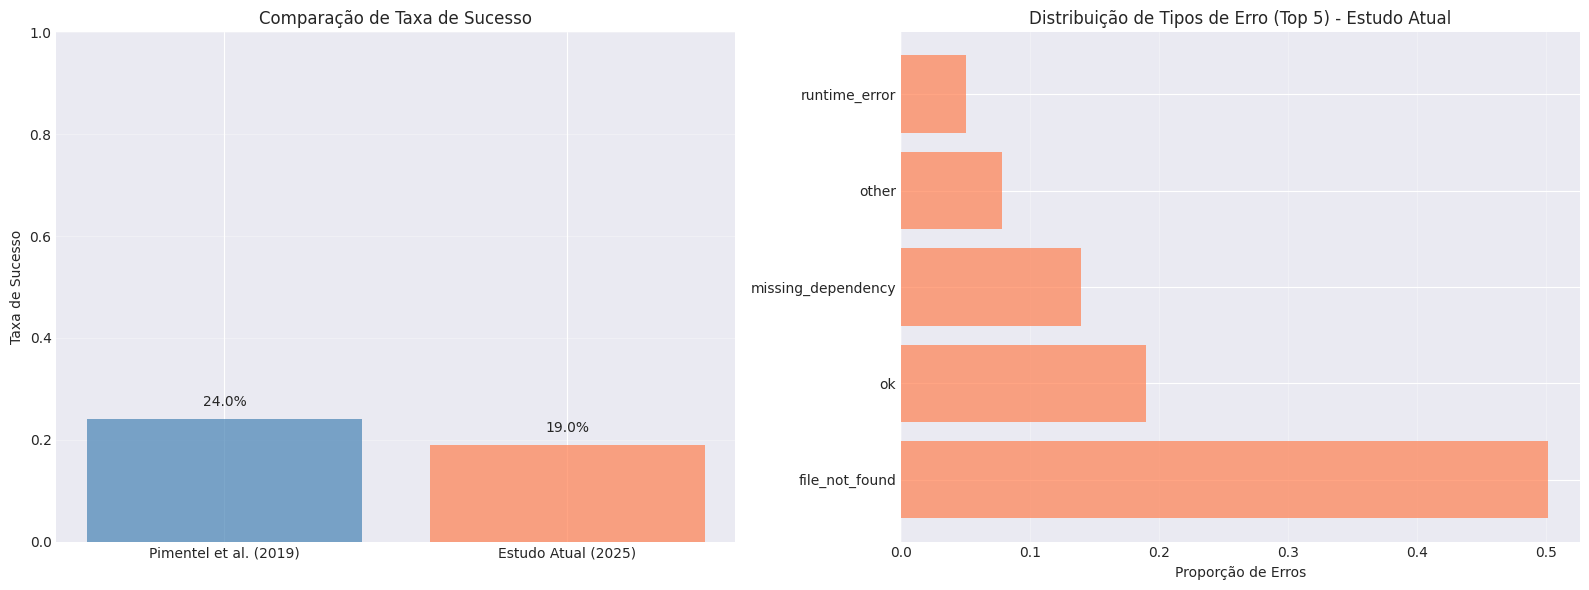


✓ Comparação salva em: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/rq8_literature_comparison.csv
✓ Figura salva em: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures/rq8_literature_comparison.png


In [37]:
# === BLOCO 8: ANÁLISE EXPLORATÓRIA - COMPARAÇÃO COM LITERATURA ===

print("📊 Bloco 8: Análise Exploratória - Comparação com Literatura\n")

if df_master.empty:
    print("⚠️  df_master está vazio. Verifique o Bloco 1.")
else:
    # Calcular métricas principais do estudo atual
    total_notebooks = len(df_master)
    exec_ok_count = df_master['exec_ok'].map(to_bool).sum()
    success_rate = exec_ok_count / total_notebooks if total_notebooks > 0 else 0
    
    # Distribuição de tipos de erro
    error_dist = df_master['exec_error_type'].value_counts()
    
    print(f"Estudo Atual (2025):")
    print(f"  Total de notebooks: {total_notebooks}")
    print(f"  Taxa de sucesso: {success_rate:.1%} ({exec_ok_count}/{total_notebooks})")
    print(f"\nDistribuição de erros:")
    for error_type, count in error_dist.items():
        print(f"  {error_type}: {count} ({count/total_notebooks*100:.1f}%)")
    
    # Comparação com Pimentel et al. (2019) - valores de referência
    # Nota: Estes são valores aproximados baseados no artigo
    pimentel_2019 = {
        'total_notebooks': 1000000,  # Aproximado
        'success_rate': 0.24,  # 24% aproximadamente
        'file_not_found_rate': 0.15,  # Aproximado
        'missing_dependency_rate': 0.10  # Aproximado
    }
    
    print(f"\nPimentel et al. (2019) - Referência:")
    print(f"  Taxa de sucesso: {pimentel_2019['success_rate']:.1%}")
    print(f"  Taxa de file_not_found: {pimentel_2019['file_not_found_rate']:.1%}")
    print(f"  Taxa de missing_dependency: {pimentel_2019['missing_dependency_rate']:.1%}")
    
    # Comparação visual
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Taxa de sucesso
    comparison_data = pd.DataFrame({
        'Estudo': ['Pimentel et al. (2019)', 'Estudo Atual (2025)'],
        'Taxa de Sucesso': [pimentel_2019['success_rate'], success_rate]
    })
    
    axes[0].bar(comparison_data['Estudo'], comparison_data['Taxa de Sucesso'], 
                color=['steelblue', 'coral'], alpha=0.7)
    axes[0].set_ylabel('Taxa de Sucesso')
    axes[0].set_title('Comparação de Taxa de Sucesso')
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(comparison_data['Taxa de Sucesso']):
        axes[0].text(i, v + 0.02, f'{v:.1%}', ha='center', va='bottom')
    
    # Distribuição de erros (top 5)
    current_errors = error_dist.head(5) / total_notebooks
    axes[1].barh(current_errors.index, current_errors.values, color='coral', alpha=0.7)
    axes[1].set_xlabel('Proporção de Erros')
    axes[1].set_title('Distribuição de Tipos de Erro (Top 5) - Estudo Atual')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'rq8_literature_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Salvar comparação
    comparison_df = pd.DataFrame({
        'métrica': ['taxa_sucesso', 'taxa_file_not_found', 'taxa_missing_dependency'],
        'pimentel_2019': [
            pimentel_2019['success_rate'],
            pimentel_2019['file_not_found_rate'],
            pimentel_2019['missing_dependency_rate']
        ],
        'estudo_atual_2025': [
            success_rate,
            (error_dist.get('file_not_found', 0) / total_notebooks),
            (error_dist.get('missing_dependency', 0) / total_notebooks)
        ]
    })
    comparison_df['diferença'] = comparison_df['estudo_atual_2025'] - comparison_df['pimentel_2019']
    
    comparison_df.to_csv(DATA_OUTPUTS / 'rq8_literature_comparison.csv', index=False)
    
    print(f"\n✓ Comparação salva em: {DATA_OUTPUTS / 'rq8_literature_comparison.csv'}")
    print(f"✓ Figura salva em: {FIG_DIR / 'rq8_literature_comparison.png'}")





## BLOCO 5: Exportar Artefatos

Exportar tabelas e figuras finais para uso no paper. Todas as figuras são salvas em `data/outputs/figures/` e tabelas em `data/outputs/`.

In [38]:
# Exportar artefatos finais

print("📋 Bloco 5: Exportar Artefatos\n")

print("="*60)
print("ARTEFATOS EXPORTADOS")
print("="*60)

# Resumo de artefatos gerados
artifacts = []

# RQ1
if (DATA_OUTPUTS / 'rq1_summary.csv').exists():
    artifacts.append("✓ rq1_summary.csv")
if (DATA_OUTPUTS / 'rq1_errors_top.csv').exists():
    artifacts.append("✓ rq1_errors_top.csv")
if (FIG_DIR / 'rq1_exec_ok_by_python.png').exists():
    artifacts.append("✓ rq1_exec_ok_by_python.png")
if (FIG_DIR / 'rq1_exec_ok_by_envspec.png').exists():
    artifacts.append("✓ rq1_exec_ok_by_envspec.png")

# RQ2
if (DATA_OUTPUTS / 'rq2_bad_practices_2025.csv').exists():
    artifacts.append("✓ rq2_bad_practices_2025.csv")
if (DATA_OUTPUTS / 'rq2_pimentel_comparison.csv').exists():
    artifacts.append("✓ rq2_pimentel_comparison.csv")
if (FIG_DIR / 'rq2_pimentel_comparison.png').exists():
    artifacts.append("✓ rq2_pimentel_comparison.png")

# RQ3
if (DATA_OUTPUTS / 'rq3_coefficients.csv').exists():
    artifacts.append("✓ rq3_coefficients.csv")
if (DATA_OUTPUTS / 'rq3_factor_importance.csv').exists():
    artifacts.append("✓ rq3_factor_importance.csv")
if (FIG_DIR / 'rq3_feature_importance.png').exists():
    artifacts.append("✓ rq3_feature_importance.png")

# Master dataset
if (DATA_OUTPUTS / 'master_notebooks_merged.csv').exists():
    artifacts.append("✓ master_notebooks_merged.csv")

print("\nArtefatos disponíveis:")
for artifact in artifacts:
    print(f"  {artifact}")

print(f"\n📁 Diretório de figuras: {FIG_DIR}")
print(f"📁 Diretório de tabelas: {DATA_OUTPUTS}")

print("\n" + "="*60)
print("Pipeline de análise concluído!")
print("="*60)


📋 Bloco 5: Exportar Artefatos

ARTEFATOS EXPORTADOS

Artefatos disponíveis:
  ✓ rq1_summary.csv
  ✓ rq1_errors_top.csv
  ✓ rq1_exec_ok_by_python.png
  ✓ rq1_exec_ok_by_envspec.png
  ✓ rq2_bad_practices_2025.csv
  ✓ rq2_pimentel_comparison.csv
  ✓ rq2_pimentel_comparison.png
  ✓ rq3_factor_importance.csv
  ✓ rq3_feature_importance.png
  ✓ master_notebooks_merged.csv

📁 Diretório de figuras: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs/figures
📁 Diretório de tabelas: /home/asu/reproducibility_of_jupyter_notebooks-1/data/outputs

Pipeline de análise concluído!


---

## Conclusão

Este notebook implementa um pipeline completo de pesquisa sobre reprodutibilidade de notebooks Jupyter. O pipeline é flexível e pode:

- **Usar dados existentes** (modo `use_existing`)
- **Coletar novos dados** (modo `collect_new`)
- **Re-executar notebooks** (modo `reexecute_existing`)

### Próximos Passos

1. Execute todas as células sequencialmente
2. Verifique os resultados e visualizações
3. Analise o relatório final consolidado
4. Exporte os resultados para uso em publicações

### Notas

- Todos os parâmetros podem ser ajustados na **Etapa 0**
- O pipeline lida graciosamente com dados ausentes
- As visualizações são geradas automaticamente
- Um relatório markdown é criado automaticamente (quando aplicável)
